In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv( "cleaned_data.csv")

In [6]:
df.head()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2022-01-01 00:00:00,Mouse,Accessories,East,3,3474,565.00
1,2022-01-01 00:00:00,Monitor,Accessories,South,8,1296,273.97
2,2022-01-01 00:00:00,Keyboard,Accessories,East,6,6372,570.75
3,2022-01-01 00:00:00,Tablet,Electronics,North,9,9234,2523.67
4,2022-01-01 00:00:00,Headphones,Accessories,South,7,3941,628.96


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3500 non-null   object 
 1   Product Name  3500 non-null   object 
 2   Category      3500 non-null   object 
 3   Region        3500 non-null   object 
 4   Quantity      3500 non-null   int64  
 5   Sales         3500 non-null   int64  
 6   Profit        3500 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 191.5+ KB


In [8]:
df.describe()

,Quantity,Sales,Profit
count,3500.000000,3500.000000,3500.000000
mean,4.931714,3047.966000,527.047203
std,2.575895,2440.213237,504.139732
min,1.000000,51.000000,6.970000
25%,3.000000,1049.500000,158.695000
50%,5.000000,2350.500000,361.070000
75%,7.000000,4537.000000,729.125000
max,9.000000,10782.000000,2946.930000


In [10]:
df.columns

Index(['Order Date', 'Product Name', 'Category', 'Region', 'Quantity', 'Sales',
       'Profit'],
      dtype='object')

In [11]:
df['Order Date']=pd.to_datetime(df['Order Date'])

In [13]:
df['Month']=df['Order Date'].dt.to_period('M')

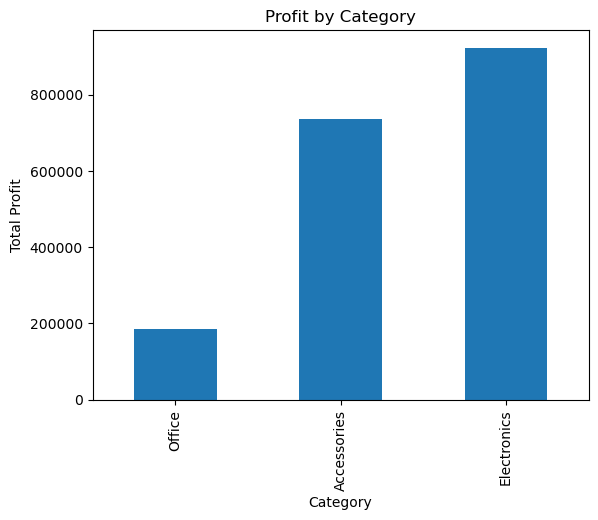

In [18]:
category_profit = df.groupby('Category')['Profit'].sum().sort_values()

category_profit.plot(kind='bar')
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.show()

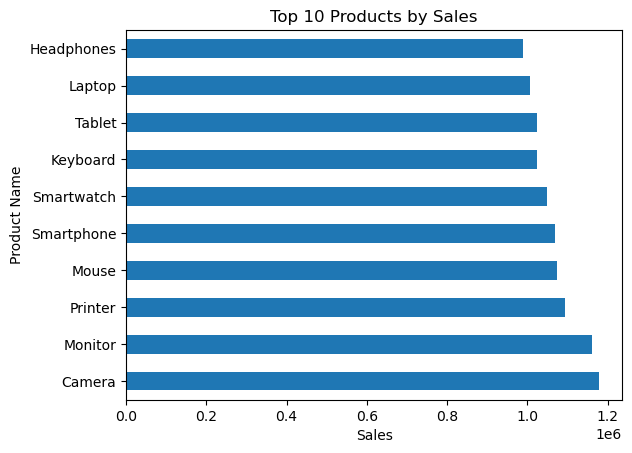

In [19]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='barh')
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product Name")
plt.show()

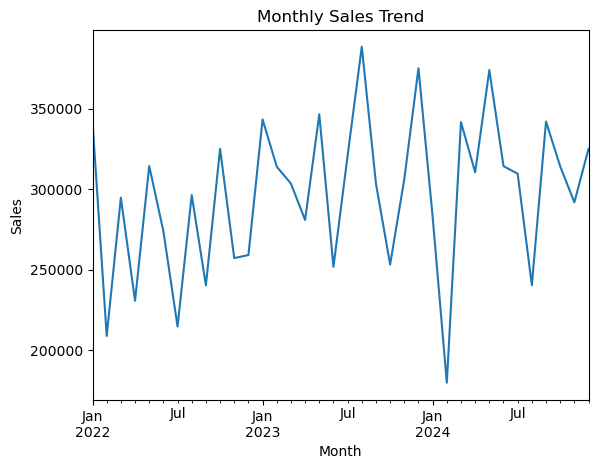

In [20]:
monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

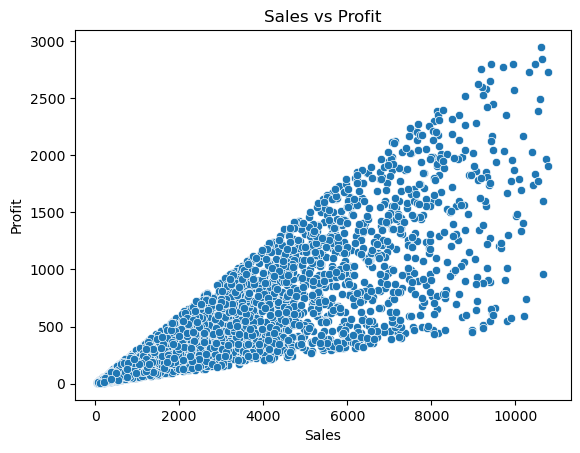

In [21]:
sns.scatterplot(x='Sales', y='Profit', data=df)

plt.title("Sales vs Profit")
plt.show()

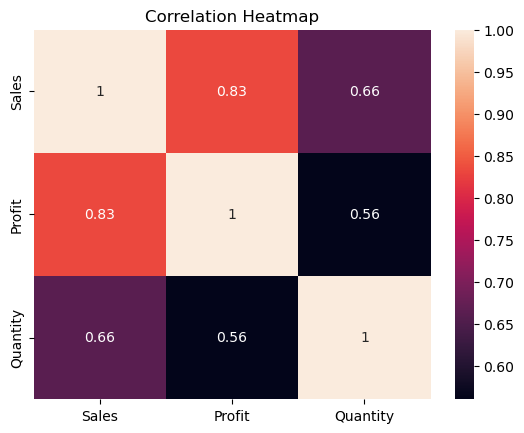

In [22]:
corr = df[['Sales','Profit','Quantity']].corr()

sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap")
plt.show()